# Face Mask Detection — ViT + Faster R-CNN

Two complementary models trained on the [Face Mask Detection](https://www.kaggle.com/datasets/andrewmvd/face-mask-detection) dataset:

| Model | Type | Classes |
|-------|------|---------|
| **ViT Base** | Image classifier | `with_mask` · `without_mask` · `mask_weared_incorrectly` |
| **Faster R-CNN** | Object detector | `with_mask` · `without_mask` · `mask_weared_incorrect` |

Run cells **top-to-bottom**.

- The dataset is stored in the repo at `data/face-mask-detection`.
- The temporary KaggleHub download is removed after it is copied locally.
- The final cell copies exported ONNX models into the repo's `model/` directory for the StreamCamServer.
- The Faster R-CNN section still requires a Python build where `torchvision` imports cleanly.
- Important note: this notebook is macos mps optimized. (not cpu or cuda optimized)

In [1]:
# ── Verify that this notebook is running from the project .venv ──────────
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "config" / "models.json").exists():
            return candidate
    raise RuntimeError("Could not locate the StreamCamServer project root from the current working directory.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
EXPORT_DIR = NOTEBOOK_DIR / "exports"
DATA_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_VENV = PROJECT_ROOT / ".venv"
EXPECTED_PYTHON = EXPECTED_VENV / ("Scripts/python.exe" if sys.platform == "win32" else "bin/python")
print("Project root:", PROJECT_ROOT)
print("Notebook Python:", sys.executable)
print("Expected venv  :", EXPECTED_PYTHON)

if Path(sys.executable).resolve() != EXPECTED_PYTHON.resolve():
    raise RuntimeError(
        "This notebook is not running from the project's .venv. "
        "Run `uv sync --group notebook`, then start Jupyter with `uv run --group notebook jupyter lab` or switch the kernel to the .venv interpreter, then rerun the notebook."
    )

Project root: /Users/nasser/ettbtm/work/DEBI/StreamCamServer
Notebook Python: /Users/nasser/ettbtm/work/DEBI/StreamCamServer/.venv/bin/python
Expected venv  : /Users/nasser/ettbtm/work/DEBI/StreamCamServer/.venv/bin/python


In [2]:
import shutil
import kagglehub

DATASET_PATH = DATA_DIR / "face-mask-detection"

if not DATASET_PATH.exists():
    downloaded_path = kagglehub.dataset_download("andrewmvd/face-mask-detection")
    if not isinstance(downloaded_path, str) or not downloaded_path:
        raise RuntimeError("kagglehub.dataset_download returned an empty path")

    source_path = Path(downloaded_path).resolve()
    shutil.copytree(source_path, DATASET_PATH)
    shutil.rmtree(source_path)
    print("Copied dataset into:", DATASET_PATH)
    print("Removed temporary download:", source_path)
else:
    print("Using existing dataset at:", DATASET_PATH)

print("Dataset path:", DATASET_PATH)

Using existing dataset at: /Users/nasser/ettbtm/work/DEBI/StreamCamServer/data/face-mask-detection
Dataset path: /Users/nasser/ettbtm/work/DEBI/StreamCamServer/data/face-mask-detection


/Users/nasser/ettbtm/work/DEBI/StreamCamServer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1 — ViT Image Classifier

Classifies each face crop into three categories:
`with_mask` · `without_mask` · `mask_weared_incorrectly`

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd
from PIL import Image

images_path = DATASET_PATH / "images"
annotations_path = DATASET_PATH / "annotations"

def require_child_text(element: ET.Element, tag: str) -> str:
    child = element.find(tag)
    if child is None or child.text is None:
        raise ValueError(f"Missing <{tag}> in XML annotation")
    return child.text.strip()

def parse_xml_clf(xml_file: Path) -> tuple[str, list[str]]:
    tree = ET.parse(xml_file)
    root = tree.getroot()
    filename = require_child_text(root, "filename")
    labels = [require_child_text(obj, "name") for obj in root.findall("object")]
    return filename, labels

data = []
for xml_file in annotations_path.iterdir():
    fname, labels = parse_xml_clf(xml_file)
    if 'with_mask' in labels and 'without_mask' in labels:
        final_label = 'mask_weared_incorrectly'
    elif 'without_mask' in labels:
        final_label = 'without_mask'
    else:
        final_label = 'with_mask'
    data.append({'image_path': str(images_path / fname), 'label': final_label})

df = pd.DataFrame(data)
label2id = {label: i for i, label in enumerate(sorted(df['label'].unique()))}
id2label  = {i: label for label, i in label2id.items()}
df['label_id'] = df['label'].apply(lambda label: label2id[label]).astype('int64')

print(f"Dataset size : {len(df)}")
print(f"label2id     : {label2id}")
display(df.head())

Dataset size : 853
label2id     : {'mask_weared_incorrectly': 0, 'with_mask': 1, 'without_mask': 2}


,image_path,label,label_id
0,/Users/nasser/ettbtm/work/DEBI/StreamCamServer...,without_mask,2
1,/Users/nasser/ettbtm/work/DEBI/StreamCamServer...,without_mask,2
2,/Users/nasser/ettbtm/work/DEBI/StreamCamServer...,with_mask,1
3,/Users/nasser/ettbtm/work/DEBI/StreamCamServer...,mask_weared_incorrectly,0
4,/Users/nasser/ettbtm/work/DEBI/StreamCamServer...,with_mask,1


In [4]:
from transformers import ViTForImageClassification
import numpy as np
import torch

torch.set_float32_matmul_precision("high")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

model_checkpoint = "google/vit-base-patch16-224-in21k"
VIT_IMAGE_SIZE = 224
VIT_MEAN = np.array([0.5, 0.5, 0.5], dtype=np.float32)
VIT_STD = np.array([0.5, 0.5, 0.5], dtype=np.float32)

def vit_preprocess_images(images) -> torch.Tensor:
    batch = []
    for image in images:
        resized = image.convert("RGB").resize((VIT_IMAGE_SIZE, VIT_IMAGE_SIZE))
        arr = np.asarray(resized, dtype=np.float32) / 255.0
        arr = (arr - VIT_MEAN) / VIT_STD
        batch.append(arr.transpose(2, 0, 1))
    return torch.tensor(np.stack(batch), dtype=torch.float32)

vit_model = ViTForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

print(f"Model   : {model_checkpoint}")
print(f"Device  : {DEVICE}")
print(f"Classes : {list(id2label.values())}")

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 6381.96it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model   : google/vit-base-patch16-224-in21k
Device  : mps
Classes : ['mask_weared_incorrectly', 'with_mask', 'without_mask']


In [5]:
from datasets import Dataset, Image as HFImage
from transformers import TrainingArguments, Trainer

PREPROCESS_DIR = NOTEBOOK_DIR / "cache"
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

# Build HuggingFace dataset (use integer label_id column)
hf_df = pd.DataFrame(df[['image_path', 'label_id']].copy())
hf_df.columns = ['image_path', 'label']
full_dataset = Dataset.from_pandas(hf_df, preserve_index=False).train_test_split(
    test_size=0.2,
    seed=42,
)

train_ds = full_dataset['train']
eval_ds  = full_dataset['test']

train_ds = train_ds.cast_column("image_path", HFImage())
eval_ds = eval_ds.cast_column("image_path", HFImage())

def preprocess_batch(batch):
    images = [img.convert("RGB") for img in batch['image_path']]
    pixel_values = vit_preprocess_images(images).numpy()
    return {
        'pixel_values': [arr for arr in pixel_values],
        'labels': batch['label'],
    }

prepared_train_ds = train_ds.map(
    preprocess_batch,
    batched=True,
    batch_size=32,
    remove_columns=["image_path"],
    load_from_cache_file=True,
    cache_file_name=str(PREPROCESS_DIR / "vit_train.arrow"),
    desc="Preprocessing train images",
)
prepared_eval_ds = eval_ds.map(
    preprocess_batch,
    batched=True,
    batch_size=32,
    remove_columns=["image_path"],
    load_from_cache_file=True,
    cache_file_name=str(PREPROCESS_DIR / "vit_eval.arrow"),
    desc="Preprocessing eval images",
)

prepared_train_ds.set_format(type="torch", columns=["pixel_values", "labels"])
prepared_eval_ds.set_format(type="torch", columns=["pixel_values", "labels"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": float((preds == labels).mean())}

training_args = TrainingArguments(
    output_dir="./vit-face-mask",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    fp16=False,
    bf16=False,
    logging_steps=20,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    save_total_limit=1,
    disable_tqdm=True,
    report_to=[],
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=0,
)

trainer = Trainer(
    model=vit_model,
    args=training_args,
    train_dataset=prepared_train_ds,
    eval_dataset=prepared_eval_ds,
    compute_metrics=compute_metrics,
)

print(f"Train : {len(prepared_train_ds)} | Eval : {len(prepared_eval_ds)}")

Preprocessing eval images: 100%|██████████| 171/171 [00:02<00:00, 81.46 examples/s]


Train : 682 | Eval : 171


In [6]:
trainer.train()

{'loss': '0.957', 'grad_norm': '1.54', 'learning_rate': '1.705e-05', 'epoch': '0.4651'}
{'loss': '0.7568', 'grad_norm': '1.276', 'learning_rate': '1.395e-05', 'epoch': '0.9302'}
{'eval_loss': '0.7114', 'eval_accuracy': '0.6901', 'eval_runtime': '10.94', 'eval_samples_per_second': '15.63', 'eval_steps_per_second': '1.005', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it]


{'loss': '0.6245', 'grad_norm': '1.436', 'learning_rate': '1.085e-05', 'epoch': '1.395'}
{'loss': '0.5832', 'grad_norm': '1.447', 'learning_rate': '7.752e-06', 'epoch': '1.86'}
{'eval_loss': '0.6293', 'eval_accuracy': '0.7193', 'eval_runtime': '10.82', 'eval_samples_per_second': '15.81', 'eval_steps_per_second': '1.017', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


{'loss': '0.5233', 'grad_norm': '1.114', 'learning_rate': '4.651e-06', 'epoch': '2.326'}
{'loss': '0.5314', 'grad_norm': '1.26', 'learning_rate': '1.55e-06', 'epoch': '2.791'}
{'eval_loss': '0.607', 'eval_accuracy': '0.7427', 'eval_runtime': '10.59', 'eval_samples_per_second': '16.14', 'eval_steps_per_second': '1.038', 'epoch': '3'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]


{'train_runtime': '383.3', 'train_samples_per_second': '5.338', 'train_steps_per_second': '0.337', 'train_loss': '0.6499', 'epoch': '3'}


TrainOutput(global_step=129, training_loss=0.6498950839966766, metrics={'train_runtime': 383.3122, 'train_samples_per_second': 5.338, 'train_steps_per_second': 0.337, 'train_loss': 0.6498950839966766, 'epoch': 3.0})

In [7]:
results = trainer.evaluate()
print("Evaluation results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

{'eval_loss': '0.607', 'eval_accuracy': '0.7427', 'eval_runtime': '12.56', 'eval_samples_per_second': '13.61', 'eval_steps_per_second': '0.876', 'epoch': '3'}
Evaluation results:
  eval_loss: 0.6070
  eval_accuracy: 0.7427
  eval_runtime: 12.5626
  eval_samples_per_second: 13.6120
  eval_steps_per_second: 0.8760
  epoch: 3.0000


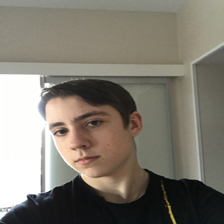

Prediction : with_mask  (40.4%)


In [8]:
def predict_mask_vit(image_path: str):
    image = Image.open(image_path).convert("RGB")
    inputs = {
        'pixel_values': vit_preprocess_images([image]).to(vit_model.device)
    }
    with torch.no_grad():
        logits = vit_model(**inputs).logits
    idx   = logits.argmax(-1).item()
    label = id2label[idx]
    prob  = torch.softmax(logits, dim=-1)[0, idx].item()
    display(image.resize((224, 224)))
    print(f"Prediction : {label}  ({prob:.1%})")

predict_mask_vit(df.iloc[0]['image_path'])

## Section 2 — Faster R-CNN Object Detector

Detects faces and classifies them directly, returning bounding boxes.
Uses ResNet-50 + FPN backbone pretrained on COCO.

Classes: `with_mask` · `without_mask` · `mask_weared_incorrect`
> **Note:** `GeneralizedRCNNTransform` normalises the input internally — do **not** pre-normalise images; pass raw `[0, 1]` tensors.

In [9]:
import os
import cv2
import time
import random
from pathlib import Path
from typing import Dict, List, Tuple, cast

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import matplotlib.pyplot as plt

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from streamcamserver.training.data import FaceMaskDataset, collate_fn

# ── Config ───────────────────────────────────────────────────────────────
DATASET_ROOT   = DATASET_PATH
CHECKPOINT_DIR = NOTEBOOK_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# 0 = background (required by Faster R-CNN)
CLASSES     = ["__background__", "with_mask", "without_mask", "mask_weared_incorrect"]
NUM_CLASSES = len(CLASSES)

EPOCHS       = 10
BATCH_SIZE   = 4
LR           = 0.005
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
LR_STEP_SIZE = 7
LR_GAMMA     = 0.1
TRAIN_SPLIT  = 0.8
VAL_SPLIT    = 0.1

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

IN_NOTEBOOK = "ipykernel" in sys.modules
NUM_WORKERS = 1 if IN_NOTEBOOK else min(4, os.cpu_count() or 1)
PIN_MEMORY = False

COLOR_MAP = {
    "with_mask":             (0, 200,   0),
    "without_mask":          (0,   0, 220),
    "mask_weared_incorrect": (0, 165, 255),
}

print(f"Device         : {DEVICE}")
print(f"Project root   : {PROJECT_ROOT}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Classes        : {CLASSES[1:]}")
print(f"Num workers    : {NUM_WORKERS}")
if IN_NOTEBOOK:
    print("Data loading   : capped to 1 worker in notebooks to keep the laptop responsive.")
if DEVICE.type == "cpu":
    print("Warning        : MPS is unavailable, so training will stay on CPU.")

Device         : mps
Project root   : /Users/nasser/ettbtm/work/DEBI/StreamCamServer
Checkpoint dir : /Users/nasser/ettbtm/work/DEBI/StreamCamServer/notebooks/checkpoints
Classes        : ['with_mask', 'without_mask', 'mask_weared_incorrect']
Num workers    : 4
Data loading   : multiprocessing enabled via imported dataset module.


In [10]:
# Dataset and collate function live in streamcamserver.training.data so DataLoader
# workers can import them when multiprocessing is enabled on macOS.
print("Using FaceMaskDataset from streamcamserver.training.data")

Using FaceMaskDataset from faster_rcnn_data.py


In [11]:
def build_model(num_classes: int = NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """Faster R-CNN with ResNet-50 + FPN backbone, COCO-pretrained head replaced."""
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
    model   = fasterrcnn_resnet50_fpn(weights=weights)
    box_predictor = cast(FastRCNNPredictor, model.roi_heads.box_predictor)
    in_features = box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [12]:
def split_dataset(seed: int = 42) -> Tuple[List[Path], List[Path], List[Path]]:
    """Return (train_paths, val_paths, test_paths)."""
    images_dir = DATASET_ROOT / "images"
    ann_dir    = DATASET_ROOT / "annotations"
    all_images = sorted(images_dir.glob("*.png"))
    all_images = [p for p in all_images if (ann_dir / (p.stem + ".xml")).exists()]

    if not all_images:
        raise RuntimeError(f"No annotated images found under {DATASET_ROOT}")

    random.seed(seed)
    random.shuffle(all_images)

    n       = len(all_images)
    n_train = int(n * TRAIN_SPLIT)
    n_val   = int(n * VAL_SPLIT)

    train = all_images[:n_train]
    val   = all_images[n_train : n_train + n_val]
    test  = all_images[n_train + n_val :]

    print(f"Split → Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
    return train, val, test

train_paths, val_paths, test_paths = split_dataset()

Split → Train: 682 | Val: 85 | Test: 86


In [13]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0.0
    for i, (images, targets) in enumerate(data_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = cast(dict[str, torch.Tensor], model(images, targets))
        losses = torch.stack(list(loss_dict.values())).sum()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        if (i + 1) % 10 == 0 or (i + 1) == len(data_loader):
            print(f"  Epoch {epoch} [{i+1}/{len(data_loader)}]  "
                  f"loss={losses.item():.4f}  "
                  f"(cls={loss_dict['loss_classifier'].item():.3f}  "
                  f"box={loss_dict['loss_box_reg'].item():.3f})")
    return total_loss / len(data_loader)


@torch.no_grad()
def validate(model, data_loader, device):
    """Compute avg loss on the validation set (model stays in train() for loss access)."""
    model.train()
    total_loss = 0.0
    for images, targets in data_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = cast(dict[str, torch.Tensor], model(images, targets))
        total_loss += torch.stack(list(loss_dict.values())).sum().item()
    return total_loss / len(data_loader)


def plot_loss(history: Dict):
    plt.figure(figsize=(9, 5))
    plt.plot(history["train_loss"], label="Train Loss", color="#2563eb", lw=2)
    plt.plot(history["val_loss"],   label="Val Loss",   color="#dc2626", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Faster R-CNN — Training & Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out = CHECKPOINT_DIR / "loss_curve.png"
    plt.savefig(out, dpi=150)
    plt.close()
    print(f"Loss curve → {out}")

In [ ]:
train_ds = FaceMaskDataset(train_paths, DATASET_ROOT, CLASSES, augment=True)
val_ds   = FaceMaskDataset(val_paths,   DATASET_ROOT, CLASSES, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
                          pin_memory=PIN_MEMORY, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
                          pin_memory=PIN_MEMORY, collate_fn=collate_fn)

rcnn_model = build_model(pretrained=True).to(DEVICE)

params    = [p for p in rcnn_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print(f"\n{'='*60}")
print(f"  Faster R-CNN  |  Device: {DEVICE}  |  Epochs: {EPOCHS}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    t0         = time.time()
    train_loss = train_one_epoch(rcnn_model, optimizer, train_loader, DEVICE, epoch)
    val_loss   = validate(rcnn_model, val_loader, DEVICE)
    scheduler.step()

    elapsed = time.time() - t0
    print(f"\nEpoch {epoch:02d}/{EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  t={elapsed:.0f}s")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch":            epoch,
            "model_state_dict": rcnn_model.state_dict(),
            "val_loss":         val_loss,
            "num_classes":      NUM_CLASSES,
            "classes":          CLASSES,
        }, CHECKPOINT_DIR / "best_model.pth")
        print(f"  ✅ Saved best checkpoint (val_loss={val_loss:.4f})")

    if epoch % 5 == 0:
        torch.save({"epoch": epoch, "model_state_dict": rcnn_model.state_dict()},
                   CHECKPOINT_DIR / f"epoch_{epoch:03d}.pth")

print(f"\n✅ Training complete — best val loss: {best_val_loss:.4f}")
plot_loss(history)


  Faster R-CNN  |  Device: mps  |  Epochs: 10



In [ ]:
def load_rcnn_model(checkpoint_path: str = "") -> nn.Module:
    model     = build_model(pretrained=False).to(DEVICE)
    ckpt_path = checkpoint_path or str(CHECKPOINT_DIR / "best_model.pth")
    ckpt      = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"Loaded from {ckpt_path}  (epoch {ckpt.get('epoch', '?')})")
    return model


@torch.no_grad()
def predict_image(model: nn.Module, img_path: str,
                  conf_threshold: float = 0.5,
                  save_path: str = "prediction.jpg") -> str:
    """
    Run inference on a single image, draw bounding boxes, save and display.

    Images are passed as [0, 1] float tensors — Faster R-CNN normalises internally.
    Do NOT pre-normalise with ImageNet mean/std.
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # TF.to_tensor: HWC uint8 → CHW float32 in [0, 1]. No ImageNet normalisation here.
    img_tensor  = TF.to_tensor(img_rgb).to(DEVICE)
    predictions = model([img_tensor])[0]

    boxes  = predictions["boxes"].cpu().numpy()
    labels = predictions["labels"].cpu().numpy()
    scores = predictions["scores"].cpu().numpy()

    vis = img_bgr.copy()
    kept = 0
    for box, lbl, score in zip(boxes, labels, scores):
        if score < conf_threshold:
            continue
        kept += 1
        x1, y1, x2, y2 = map(int, box)
        name  = CLASSES[lbl]
        color = COLOR_MAP.get(name, (180, 180, 180))
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        text = f"{name} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(vis, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(vis, text, (x1 + 2, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

    cv2.imwrite(save_path, vis)
    print(f"Detections : {kept}  |  saved → {save_path}")

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Detections: {kept}  (threshold={conf_threshold})")
    plt.tight_layout()
    plt.show()
    return save_path

In [ ]:
def compute_iou(box_a, box_b) -> float:
    xa = max(box_a[0], box_b[0])
    ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2])
    yb = min(box_a[3], box_b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


@torch.no_grad()
def evaluate_map(checkpoint_path: str = "",
                 iou_threshold: float = 0.5,
                 conf_threshold: float = 0.5):
    """Per-class precision / recall / F1 + mAP@0.5 on the test split."""
    model = load_rcnn_model(checkpoint_path)
    model.eval()

    test_ds     = FaceMaskDataset(test_paths, DATASET_ROOT, CLASSES, augment=False)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                             num_workers=0, collate_fn=collate_fn)

    stats = {c: {"tp": 0, "fp": 0, "fn": 0} for c in CLASSES[1:]}

    for images, targets in test_loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)[0]
        tgt    = targets[0]

        gt_boxes  = tgt["boxes"].numpy()
        gt_labels = tgt["labels"].numpy()
        pb = preds["boxes"].cpu().numpy()
        pl = preds["labels"].cpu().numpy()
        ps = preds["scores"].cpu().numpy()

        keep   = ps >= conf_threshold
        pb, pl = pb[keep], pl[keep]

        matched_gt = set()
        for pred_box, pred_lbl in zip(pb, pl):
            cls = CLASSES[pred_lbl]
            best_iou, best_j = 0.0, -1
            for j, (gt_box, gt_lbl) in enumerate(zip(gt_boxes, gt_labels)):
                if j in matched_gt or CLASSES[gt_lbl] != cls:
                    continue
                iou = compute_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_threshold:
                stats[cls]["tp"] += 1
                matched_gt.add(best_j)
            else:
                stats[cls]["fp"] += 1

        for j, gt_lbl in enumerate(gt_labels):
            if j not in matched_gt:
                stats[CLASSES[gt_lbl]]["fn"] += 1

    print(f"\n{'='*55}")
    print(f"  Evaluation  (IoU≥{iou_threshold}, conf≥{conf_threshold})")
    print(f"{'='*55}")
    print(f"  {'Class':<30} {'Prec':>6} {'Rec':>6} {'F1':>6}")
    print(f"  {'-'*46}")
    map_vals = []
    for cls, s in stats.items():
        tp, fp, fn = s["tp"], s["fp"], s["fn"]
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        map_vals.append(prec)
        print(f"  {cls:<30} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f}")
    print(f"  {'-'*46}")
    print(f"  {'mAP@0.5':<30} {np.mean(map_vals):>6.3f}")
    print(f"{'='*55}\n")


# ── Run evaluation ──────────────────────────────────────────────────────────
ckpt_path = str(CHECKPOINT_DIR / "best_model.pth")
if os.path.exists(ckpt_path):
    evaluate_map(checkpoint_path=ckpt_path, conf_threshold=0.5)
else:
    print(f"No checkpoint at {ckpt_path} — run training first.")

In [ ]:
# Quick smoke-test on the first test image
if test_paths:
    rcnn_model.eval()
    predict_image(rcnn_model, str(test_paths[0]),
                  conf_threshold=0.5, save_path="test_prediction.jpg")
else:
    print("No test images available.")

## Section 3 — Export to ONNX

Exports both trained models to ONNX so the **StreamCamServer** can load them with ONNX Runtime.

| File | Input | Values |
|------|-------|--------|
| `vit_model.onnx` | `[1, 3, 224, 224]` | ImageNet-normalised, channels-first |
| `faster_rcnn.onnx` | `[1, 3, 640, 640]` | `[0, 1]` float, channels-first (model normalises internally) |

In [ ]:
import onnx

VIT_ONNX_PATH = EXPORT_DIR / "vit_model.onnx"

# ── Wrapper: unwrap HuggingFace SequenceClassifierOutput → plain logits tensor ──
class _ViTONNXWrapper(torch.nn.Module):
    """Thin wrapper so torch.onnx.export sees a plain Tensor output, not a dataclass."""
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return self.model(pixel_values=pixel_values).logits

vit_wrapper = _ViTONNXWrapper(vit_model.cpu())
dummy_vit   = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    torch.onnx.export(
        vit_wrapper,
        (dummy_vit,),
        str(VIT_ONNX_PATH),
        opset_version=14,
        input_names=["pixel_values"],
        output_names=["logits"],
        dynamic_axes={
            "pixel_values": {0: "batch"},
            "logits":       {0: "batch"},
        },
    )

onnx.checker.check_model(str(VIT_ONNX_PATH))
m = onnx.load(str(VIT_ONNX_PATH))
print(f"✅ {VIT_ONNX_PATH.name}")
print(f"   input  : {[i.name for i in m.graph.input]}")
print(f"   output : {[o.name for o in m.graph.output]}")
print(f"   classes: {list(id2label.values())}")

In [ ]:
# ── Wrapper: batched NCHW → (boxes, labels, scores) ─────────────────────
# Input : [1, 3, H, W], float32 in [0, 1]  — no pre-normalisation
# Model : GeneralizedRCNNTransform normalises internally with ImageNet stats
# Output: boxes [N,4] abs-coords, labels [N] float32, scores [N] float32

RCNN_ONNX_PATH = EXPORT_DIR / "faster_rcnn.onnx"

class _RCNNONNXWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()

    def forward(self, images: torch.Tensor):
        # images: [1, 3, H, W]  —  list() splits along batch dim → [[3,H,W]]
        preds = self.model(list(images))[0]
        return (
            preds["boxes"],
            preds["labels"].to(torch.float32),  # float for ONNX compatibility
            preds["scores"],
        )

# Load trained checkpoint (avoids overwriting global rcnn_model)
_export_rcnn = build_model(pretrained=False)
_ckpt = torch.load(str(CHECKPOINT_DIR / "best_model.pth"),
                   map_location="cpu", weights_only=True)
_export_rcnn.load_state_dict(_ckpt["model_state_dict"])

rcnn_wrapper = _RCNNONNXWrapper(_export_rcnn)
dummy_rcnn   = torch.zeros(1, 3, 640, 640)

# Monkey-patch: steer NMS towards the traceable code path
_orig_tracing = getattr(torchvision, '_is_tracing', None)
if _orig_tracing is not None:
    torchvision._is_tracing = lambda: True

with torch.no_grad():
    torch.onnx.export(
        rcnn_wrapper,
        (dummy_rcnn,),
        str(RCNN_ONNX_PATH),
        opset_version=12,
        input_names=["images"],
        output_names=["boxes", "labels", "scores"],
        dynamic_axes={
            "images": {0: "batch", 2: "H", 3: "W"},
            "boxes":  {0: "N"},
            "labels": {0: "N"},
            "scores": {0: "N"},
        },
    )

if _orig_tracing is not None:
    torchvision._is_tracing = _orig_tracing  # restore

onnx.checker.check_model(str(RCNN_ONNX_PATH))
m = onnx.load(str(RCNN_ONNX_PATH))
print(f"✅ {RCNN_ONNX_PATH.name}")
print(f"   input  : {[i.name for i in m.graph.input]}")
print(f"   output : {[o.name for o in m.graph.output]}")
print(f"   classes: {CLASSES[1:]}")

In [ ]:
import shutil

MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(exist_ok=True)

copies = [
    (VIT_ONNX_PATH,  MODEL_DIR / "vit_model.onnx"),
    (RCNN_ONNX_PATH, MODEL_DIR / "faster_rcnn.onnx"),
]

for src, dst in copies:
    if src.exists():
        shutil.copy(src, dst)
        print(f"✅ {src.name:<25} → {dst}  ({src.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"⚠️  {src.name} not found — run the export cell first")

print("\nFiles in model/:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name:<30}  {f.stat().st_size / 1e6:.1f} MB")
print("\n✅ Done. Start the server and switch models in the UI.")